<a href="https://colab.research.google.com/github/ashishsingh752/SolarEnergyPredictionUsingML/blob/main/weather.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing all the Necessary Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
plt.style.use('default')
import matplotlib.dates as mdates  # Import for date formatting in plots
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

Define the constant for the solar power calculation

In [4]:
# Constants for the formula
PV_rating = 1  # PV rating in kW
P_STC = 1  # Nominal PV power under standard conditions (kW)
F_PV = 0.8  # PV derating factor
G_STC = 1  # Solar radiation under STC (kW/m²)
T_STC = 25  # Temperature under STC (°C)
C_T = 0.0011  # Temperature coefficient of power (for a-Si, °C)
NOCT = 45  # Normal Operating Cell Temperature (°C)

Importing the Dataset

In [5]:
# Step 1: Load the CSV data
data = pd.read_csv('/content/weatherData.csv')

# Combine 'Date' and 'Time' columns into a single 'DATE_TIME' column
# data['DATE_TIME'] = pd.to_datetime(data['Date'] + ' ' + data['Time'], format='%d-%m-%Y %H:%M')

In [6]:
# Step 2: Data Preprocessing
# Select relevant features
features = ['Temperature', 'SolarRadiation','WindSpeed', 'PCP1', 'PCP2', 'PCP3', 'PCP4', 'PCP5', 'PCP6', 'PCP7', 'PCP8', 'PCP9', 'PCP10']
target = ['Solar Energy']

X = data[features]
y = data[target]

# Convert features to numeric, coercing errors to NaN
X[features] = X[features].apply(pd.to_numeric, errors='coerce')
y[target] = y[target].apply(pd.to_numeric, errors='coerce')

# Handle missing values
X.fillna(X.mean(), inplace=True)
y.fillna(y.mean(), inplace=True)


<ipython-input-6-07c1cbc17626>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[features] = X[features].apply(pd.to_numeric, errors='coerce')
<ipython-input-6-07c1cbc17626>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y[target] = y[target].apply(pd.to_numeric, errors='coerce')
<ipython-input-6-07c1cbc17626>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/index

In [7]:
# Step 3: Add PV power generation formula
# Calculate cell temperature (T_C)
data['T_C'] = data['Temperature'] + (NOCT - 20) * (data['SolarRadiation'] / G_STC)

# Calculate PV power using the formula
data['P_PV'] =(PV_rating * P_STC * F_PV * (data['SolarRadiation'] / G_STC) *
               (1 + (data['T_C'] - T_STC) * C_T)) / 1000


In [8]:
# Use the calculated PV power as the target variable
y = data[['P_PV']]


In [9]:
# Step 4: Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [10]:
# Step 5: Normalize the data
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

Forecasting the Weather Parameter

In [11]:
# Step 6: Build individual models for each weather parameter
# Model for Temperature ('Temperature')
model_temp = Sequential()
model_temp.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))
model_temp.add(Dropout(0.2))
model_temp.add(Dense(64, activation='relu'))
model_temp.add(Dropout(0.2))
model_temp.add(Dense(32, activation='relu'))
model_temp.add(Dense(1, activation='linear'))
model_temp.compile(optimizer=Adam(), loss='mse', metrics=['mse'])
model_temp.fit(X_train_scaled, X_train['Temperature'], epochs=50, batch_size=32, validation_data=(X_test_scaled, X_test['Temperature']))


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 215.3512 - mse: 215.3512 - val_loss: 5.5172 - val_mse: 5.5172
Epoch 2/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 11.6455 - mse: 11.6455 - val_loss: 1.2559 - val_mse: 1.2559
Epoch 3/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 7.2161 - mse: 7.2161 - val_loss: 0.4985 - val_mse: 0.4985
Epoch 4/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.7719 - mse: 5.7719 - val_loss: 0.2881 - val_mse: 0.2881
Epoch 5/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.8659 - mse: 4.8659 - val_loss: 1.6057 - val_mse: 1.6057
Epoch 6/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 4.0880 - mse: 4.0880 - val_loss: 0.3140 - val_mse: 0.3140
Epoch 7/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.4454 - mse: 3.4454 - val_loss: 0.0913 - val_mse: 0.0913
Epoch 8/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.0514 - mse: 3.0514 - val_loss: 2.1402 - val_mse: 2.1402
Epoch 9/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/ste

In [12]:
# Model for Solar Radiation ('SolarRadiation')
model_rad = Sequential()
model_rad.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))
model_rad.add(Dropout(0.2))
model_rad.add(Dense(64, activation='relu'))
model_rad.add(Dropout(0.2))
model_rad.add(Dense(32, activation='relu'))
model_rad.add(Dropout(0.2))
model_rad.add(Dense(16, activation='relu'))
model_rad.add(Dense(1, activation='relu'))
model_rad.compile(optimizer=Adam(), loss='mse', metrics=['mse'])
model_rad.fit(X_train_scaled, X_train['SolarRadiation'], epochs=50, batch_size=32, validation_data=(X_test_scaled, X_test['SolarRadiation']))


Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 56114.6758 - mse: 56114.6758 - val_loss: 418.8230 - val_mse: 418.8230
Epoch 2/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2975.3640 - mse: 2975.3640 - val_loss: 474.2028 - val_mse: 474.2028
Epoch 3/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 2546.1960 - mse: 2546.1960 - val_loss: 168.1081 - val_mse: 168.1081
Epoch 4/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 2572.5964 - mse: 2572.5964 - val_loss: 607.1733 - val_mse: 607.1733
Epoch 5/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2290.9282 - mse: 2290.9282 - val_loss: 766.2991 - val_mse: 766.2991
Epoch 6/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2320.6375 - mse: 2320.6375 - val_loss: 1672.9034 - val_mse: 1672.9034
Epoch 7/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2243.3201 - mse: 2243.3201 - val_loss: 1279.7902 - val_mse: 1279.7902
Epoch 8/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2098.8450 - mse: 2098.8450 - val_loss: 1361.3621 

In [13]:
# Model for Wind Speed ('Wind Speed')
model_wind = Sequential()
model_wind.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))
model_wind.add(Dropout(0.2))
model_wind.add(Dense(64, activation='relu'))
model_wind.add(Dropout(0.2))
model_wind.add(Dense(32, activation='relu'))
model_wind.add(Dense(1, activation='linear'))
model_wind.compile(optimizer=Adam(), loss='mse', metrics=['mse'])
model_wind.fit(X_train_scaled, X_train['WindSpeed'], epochs=50, batch_size=32, validation_data=(X_test_scaled, X_test['WindSpeed']))



Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


607/607 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 11.6230 - mse: 11.6230 - val_loss: 0.2249 - val_mse: 0.2249
Epoch 2/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.8785 - mse: 0.8785 - val_loss: 0.4016 - val_mse: 0.4016
Epoch 3/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5926 - mse: 0.5926 - val_loss: 0.5060 - val_mse: 0.5060
Epoch 4/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.4780 - mse: 0.4780 - val_loss: 0.1090 - val_mse: 0.1090
Epoch 5/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3906 - mse: 0.3906 - val_loss: 0.1693 - val_mse: 0.1693
Epoch 6/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3337 - mse: 0.3337 - val_loss: 0.2162 - val_mse: 0.2162
Epoch 7/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3072 - mse: 0.3072 - val_loss: 0.2375 - val_mse: 0.2375
Epoch 8/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2770 - mse: 0.2770 - val_loss: 0.5543 - val_mse: 0.5543
Epoch 9/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.230

In [16]:
# Model for PowerConsumption_Zone1 ('PowerConsumption_Zone1')
model_PCP1 = Sequential()
model_PCP1.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))
model_PCP1.add(Dropout(0.2))
model_PCP1.add(Dense(64, activation='relu'))
model_PCP1.add(Dropout(0.2))
model_PCP1.add(Dense(32, activation='relu'))
model_PCP1.add(Dense(1, activation='relu'))
model_PCP1.compile(optimizer=Adam(), loss='mse', metrics=['mse'])
model_PCP1.fit(X_train_scaled, X_train['PCP1'], epochs=50, batch_size=32, validation_data=(X_test_scaled, X_test['PCP1']))



/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 224.4896 - mse: 224.4896 - val_loss: 6.4400 - val_mse: 6.4400
Epoch 2/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 12.7499 - mse: 12.7499 - val_loss: 2.0267 - val_mse: 2.0267
Epoch 3/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 7.8670 - mse: 7.8670 - val_loss: 0.4980 - val_mse: 0.4980
Epoch 4/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 6.8898 - mse: 6.8898 - val_loss: 0.4836 - val_mse: 0.4836
Epoch 5/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 5.7090 - mse: 5.7090 - val_loss: 0.8204 - val_mse: 0.8204
Epoch 6/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.9424 - mse: 4.9424 - val_loss: 1.0467 - val_mse: 1.0467
Epoch 7/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4.2882 - mse: 4.2882 - val_loss: 0.3042 - val_mse: 0.3042
Epoch 8/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.7670 - mse: 3.7670 - val_loss: 0.4324 - val_mse: 0.4324
Epoch 9/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/ste

In [17]:
model_PCP2 = Sequential()
model_PCP2.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))
model_PCP2.add(Dropout(0.2))
model_PCP2.add(Dense(64, activation='relu'))
model_PCP2.add(Dropout(0.2))
model_PCP2.add(Dense(32, activation='relu'))
model_PCP2.add(Dense(1, activation='relu'))
model_PCP2.compile(optimizer=Adam(), loss='mse', metrics=['mse'])
model_PCP2.fit(X_train_scaled, X_train['PCP2'], epochs=50, batch_size=32, validation_data=(X_test_scaled, X_test['PCP2']))


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 73.8767 - mse: 73.8767 - val_loss: 2.2191 - val_mse: 2.2191
Epoch 2/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 4.8244 - mse: 4.8244 - val_loss: 0.5162 - val_mse: 0.5162
Epoch 3/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 3.2386 - mse: 3.2386 - val_loss: 0.3548 - val_mse: 0.3548
Epoch 4/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.6417 - mse: 2.6417 - val_loss: 0.1693 - val_mse: 0.1693
Epoch 5/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2.1916 - mse: 2.1916 - val_loss: 0.4275 - val_mse: 0.4275
Epoch 6/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1.8714 - mse: 1.8714 - val_loss: 0.0925 - val_mse: 0.0925
Epoch 7/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.6554 - mse: 1.6554 - val_loss: 0.2481 - val_mse: 0.2481
Epoch 8/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.3907 - mse: 1.3907 - val_loss: 0.1136 - val_mse: 0.1136
Epoch 9/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - 

In [18]:
model_PCP3 = Sequential()
model_PCP3.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))
model_PCP3.add(Dropout(0.2))
model_PCP3.add(Dense(64, activation='relu'))
model_PCP3.add(Dropout(0.2))
model_PCP3.add(Dense(32, activation='relu'))
model_PCP3.add(Dense(1, activation='relu'))
model_PCP3.compile(optimizer=Adam(), loss='mse', metrics=['mse'])
model_PCP3.fit(X_train_scaled, X_train['PCP3'], epochs=50, batch_size=32, validation_data=(X_test_scaled, X_test['PCP3']))


Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 64.4637 - mse: 64.4637 - val_loss: 1.6749 - val_mse: 1.6749
Epoch 2/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.1014 - mse: 4.1014 - val_loss: 0.7425 - val_mse: 0.7425
Epoch 3/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.7087 - mse: 2.7087 - val_loss: 0.2442 - val_mse: 0.2442
Epoch 4/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 2.1291 - mse: 2.1291 - val_loss: 0.3233 - val_mse: 0.3233
Epoch 5/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.8354 - mse: 1.8354 - val_loss: 0.1239 - val_mse: 0.1239
Epoch 6/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.5677 - mse: 1.5677 - val_loss: 0.0602 - val_mse: 0.0602
Epoch 7/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.3237 - mse: 1.3237 - val_loss: 0.4344 - val_mse: 0.4344
Epoch 8/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1.1118 - mse: 1.1118 - val_loss: 0.0573 - val_mse: 0.0573
Epoch 9/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.890

In [19]:
model_PCP4 = Sequential()
model_PCP4.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))
model_PCP4.add(Dropout(0.2))
model_PCP4.add(Dense(64, activation='relu'))
model_PCP4.add(Dropout(0.2))
model_PCP4.add(Dense(32, activation='relu'))
model_PCP4.add(Dense(1, activation='relu'))
model_PCP4.compile(optimizer=Adam(), loss='mse', metrics=['mse'])
model_PCP4.fit(X_train_scaled, X_train['PCP4'], epochs=50, batch_size=32, validation_data=(X_test_scaled, X_test['PCP4']))


Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 283.9900 - mse: 283.9900 - val_loss: 8.5485 - val_mse: 8.5485
Epoch 2/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 15.5172 - mse: 15.5172 - val_loss: 1.7362 - val_mse: 1.7362
Epoch 3/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 10.3700 - mse: 10.3700 - val_loss: 1.5132 - val_mse: 1.5132
Epoch 4/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 8.4944 - mse: 8.4944 - val_loss: 0.5306 - val_mse: 0.5306
Epoch 5/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 7.3992 - mse: 7.3992 - val_loss: 1.0955 - val_mse: 1.0955
Epoch 6/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 6.5899 - mse: 6.5899 - val_loss: 2.6757 - val_mse: 2.6757
Epoch 7/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4.8354 - mse: 4.8354 - val_loss: 12.2736 - val_mse: 12.2736
Epoch 8/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3.2735 - mse: 3.2735 - val_loss: 17.1969 - val_mse: 17.1969
Epoch 9/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - l

In [20]:
model_PCP5 = Sequential()
model_PCP5.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))
model_PCP5.add(Dropout(0.2))
model_PCP5.add(Dense(64, activation='relu'))
model_PCP5.add(Dropout(0.2))
model_PCP5.add(Dense(32, activation='relu'))
model_PCP5.add(Dense(1, activation='relu'))
model_PCP5.compile(optimizer=Adam(), loss='mse', metrics=['mse'])
model_PCP5.fit(X_train_scaled, X_train['PCP5'], epochs=50, batch_size=32, validation_data=(X_test_scaled, X_test['PCP5']))


Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 109.9046 - mse: 109.9046 - val_loss: 4.3796 - val_mse: 4.3796
Epoch 2/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 7.2510 - mse: 7.2510 - val_loss: 0.8880 - val_mse: 0.8880
Epoch 3/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.5222 - mse: 4.5222 - val_loss: 1.4898 - val_mse: 1.4898
Epoch 4/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.3339 - mse: 3.3339 - val_loss: 0.5882 - val_mse: 0.5882
Epoch 5/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.8280 - mse: 2.8280 - val_loss: 1.1199 - val_mse: 1.1199
Epoch 6/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 2.2611 - mse: 2.2611 - val_loss: 0.9825 - val_mse: 0.9825
Epoch 7/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.6515 - mse: 1.6515 - val_loss: 2.9990 - val_mse: 2.9990
Epoch 8/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.1698 - mse: 1.1698 - val_loss: 2.3214 - val_mse: 2.3214
Epoch 9/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.8

In [21]:
model_PCP6 = Sequential()
model_PCP6.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))
model_PCP6.add(Dropout(0.2))
model_PCP6.add(Dense(64, activation='relu'))
model_PCP6.add(Dropout(0.2))
model_PCP6.add(Dense(32, activation='relu'))
model_PCP6.add(Dense(1, activation='relu'))
model_PCP6.compile(optimizer=Adam(), loss='mse', metrics=['mse'])
model_PCP6.fit(X_train_scaled, X_train['PCP6'], epochs=50, batch_size=32, validation_data=(X_test_scaled, X_test['PCP6']))


Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 85.9752 - mse: 85.9752 - val_loss: 1.8078 - val_mse: 1.8078
Epoch 2/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4.9935 - mse: 4.9935 - val_loss: 0.4858 - val_mse: 0.4858
Epoch 3/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 3.3986 - mse: 3.3986 - val_loss: 0.2159 - val_mse: 0.2159
Epoch 4/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2.8119 - mse: 2.8119 - val_loss: 0.2825 - val_mse: 0.2825
Epoch 5/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2.4483 - mse: 2.4483 - val_loss: 1.2372 - val_mse: 1.2372
Epoch 6/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.1738 - mse: 2.1738 - val_loss: 1.9550 - val_mse: 1.9550
Epoch 7/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.7291 - mse: 1.7291 - val_loss: 2.7107 - val_mse: 2.7107
Epoch 8/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.3628 - mse: 1.3628 - val_loss: 3.3999 - val_mse: 3.3999
Epoch 9/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.091

In [22]:
model_PCP7 = Sequential()
model_PCP7.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))
model_PCP7.add(Dropout(0.2))
model_PCP7.add(Dense(64, activation='relu'))
model_PCP7.add(Dropout(0.2))
model_PCP7.add(Dense(32, activation='relu'))
model_PCP7.add(Dense(1, activation='relu'))
model_PCP7.compile(optimizer=Adam(), loss='mse', metrics=['mse'])
model_PCP7.fit(X_train_scaled, X_train['PCP7'], epochs=50, batch_size=32, validation_data=(X_test_scaled, X_test['PCP7']))


Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


607/607 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 53.2865 - mse: 53.2865 - val_loss: 1.3429 - val_mse: 1.3429
Epoch 2/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 3.0668 - mse: 3.0668 - val_loss: 0.3044 - val_mse: 0.3044
Epoch 3/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 2.0753 - mse: 2.0753 - val_loss: 0.1606 - val_mse: 0.1606
Epoch 4/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.6447 - mse: 1.6447 - val_loss: 0.2243 - val_mse: 0.2243
Epoch 5/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.3830 - mse: 1.3830 - val_loss: 0.4327 - val_mse: 0.4327
Epoch 6/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.1375 - mse: 1.1375 - val_loss: 0.1211 - val_mse: 0.1211
Epoch 7/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9119 - mse: 0.9119 - val_loss: 0.1281 - val_mse: 0.1281
Epoch 8/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.7301 - mse: 0.7301 - val_loss: 0.0990 - val_mse: 0.0990
Epoch 9/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.587

In [23]:
model_PCP8 = Sequential()
model_PCP8.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))
model_PCP8.add(Dropout(0.2))
model_PCP8.add(Dense(64, activation='relu'))
model_PCP8.add(Dropout(0.2))
model_PCP8.add(Dense(32, activation='relu'))
model_PCP8.add(Dense(1, activation='relu'))
model_PCP8.compile(optimizer=Adam(), loss='mse', metrics=['mse'])
model_PCP8.fit(X_train_scaled, X_train['PCP8'], epochs=50, batch_size=32, validation_data=(X_test_scaled, X_test['PCP8']))


Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 51.7632 - mse: 51.7632 - val_loss: 1.3023 - val_mse: 1.3023
Epoch 2/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 3.0389 - mse: 3.0389 - val_loss: 0.3998 - val_mse: 0.3998
Epoch 3/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.7851 - mse: 1.7851 - val_loss: 0.0819 - val_mse: 0.0819
Epoch 4/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.2021 - mse: 1.2021 - val_loss: 0.4045 - val_mse: 0.4045
Epoch 5/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9010 - mse: 0.9010 - val_loss: 0.5018 - val_mse: 0.5018
Epoch 6/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6498 - mse: 0.6498 - val_loss: 0.7811 - val_mse: 0.7811
Epoch 7/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.4099 - mse: 0.4099 - val_loss: 1.0466 - val_mse: 1.0466
Epoch 8/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2847 - mse: 0.2847 - val_loss: 1.4229 - val_mse: 1.4229
Epoch 9/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.204

In [24]:
model_PCP9 = Sequential()
model_PCP9.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))
model_PCP9.add(Dropout(0.2))
model_PCP9.add(Dense(64, activation='relu'))
model_PCP9.add(Dropout(0.2))
model_PCP9.add(Dense(32, activation='relu'))
model_PCP9.add(Dense(1, activation='relu'))
model_PCP9.compile(optimizer=Adam(), loss='mse', metrics=['mse'])
model_PCP9.fit(X_train_scaled, X_train['PCP9'], epochs=50, batch_size=32, validation_data=(X_test_scaled, X_test['PCP9']))


Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


607/607 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 52.9723 - mse: 52.9723 - val_loss: 1.5512 - val_mse: 1.5512
Epoch 2/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3.2920 - mse: 3.2920 - val_loss: 0.7130 - val_mse: 0.7130
Epoch 3/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.0486 - mse: 2.0486 - val_loss: 0.2300 - val_mse: 0.2300
Epoch 4/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.5074 - mse: 1.5074 - val_loss: 0.3308 - val_mse: 0.3308
Epoch 5/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.2010 - mse: 1.2010 - val_loss: 0.3736 - val_mse: 0.3736
Epoch 6/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.9957 - mse: 0.9957 - val_loss: 0.0502 - val_mse: 0.0502
Epoch 7/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7180 - mse: 0.7180 - val_loss: 0.3340 - val_mse: 0.3340
Epoch 8/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.5712 - mse: 0.5712 - val_loss: 0.1581 - val_mse: 0.1581
Epoch 9/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.450

In [25]:
model_PCP10 = Sequential()
model_PCP10.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))
model_PCP10.add(Dropout(0.2))
model_PCP10.add(Dense(64, activation='relu'))
model_PCP10.add(Dropout(0.2))
model_PCP10.add(Dense(32, activation='relu'))
model_PCP10.add(Dense(1, activation='relu'))
model_PCP10.compile(optimizer=Adam(), loss='mse', metrics=['mse'])
model_PCP10.fit(X_train_scaled, X_train['PCP10'], epochs=50, batch_size=32, validation_data=(X_test_scaled, X_test['PCP10']))


Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 55.3589 - mse: 55.3589 - val_loss: 1.4936 - val_mse: 1.4936
Epoch 2/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.1880 - mse: 3.1880 - val_loss: 0.2988 - val_mse: 0.2988
Epoch 3/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.9292 - mse: 1.9292 - val_loss: 0.0987 - val_mse: 0.0987
Epoch 4/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1.4458 - mse: 1.4458 - val_loss: 0.0484 - val_mse: 0.0484
Epoch 5/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.0911 - mse: 1.0911 - val_loss: 0.3257 - val_mse: 0.3257
Epoch 6/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.8672 - mse: 0.8672 - val_loss: 0.3029 - val_mse: 0.3029
Epoch 7/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6121 - mse: 0.6121 - val_loss: 1.2370 - val_mse: 1.2370
Epoch 8/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4060 - mse: 0.4060 - val_loss: 1.2643 - val_mse: 1.2643
Epoch 9/50
607/607 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.274

Choose Date to  predict the Solar and Wind Power for each Person

In [53]:
# Convert 'Date_time' column to datetime format if it's not already
data['Date_time'] = pd.to_datetime(data['Date_time'], format='%d-%m-%Y %H:%M')

# Define start and end times for the day
start_time = pd.to_datetime('01-06-2024 00:00', format='%d-%m-%Y %H:%M')
end_time = start_time + pd.Timedelta(days=1)

# Filter data for the specified day
day_data = data[(data['Date_time'] >= start_time) & (data['Date_time'] < end_time)]

# Ensure 'day_X' contains the same columns in the same order as the scaler was fitted
day_X = day_data[features]  # Use 'features' variable for consistent columns
day_X_scaled = scaler_X.transform(day_X)  # Normalize features

# Forecast weather parameters for the day
day_temp_pred_scaled = model_temp.predict(day_X_scaled)
day_rad_pred_scaled = model_rad.predict(day_X_scaled)
day_wind_pred_scaled = model_wind.predict(day_X_scaled)
day_PCP1_scaled = model_PCP1.predict(day_X_scaled)
day_PCP2_scaled = model_PCP2.predict(day_X_scaled)
day_PCP3_scaled = model_PCP3.predict(day_X_scaled)
day_PCP4_scaled = model_PCP4.predict(day_X_scaled)
day_PCP5_scaled = model_PCP5.predict(day_X_scaled)
day_PCP6_scaled = model_PCP6.predict(day_X_scaled)
day_PCP7_scaled = model_PCP7.predict(day_X_scaled)
day_PCP8_scaled = model_PCP8.predict(day_X_scaled)
day_PCP9_scaled = model_PCP9.predict(day_X_scaled)
day_PCP10_scaled = model_PCP10.predict(day_X_scaled)


# Inverse transform the predictions to get actual forecasted values
day_temp_pred = scaler_y.inverse_transform(day_temp_pred_scaled)
day_rad_pred = scaler_y.inverse_transform(day_rad_pred_scaled)
day_wind_pred = scaler_y.inverse_transform(day_wind_pred_scaled)
day_PCP1_pred = scaler_y.inverse_transform(day_PCP1_scaled)
day_PCP2_pred = scaler_y.inverse_transform(day_PCP2_scaled)
day_PCP3_pred = scaler_y.inverse_transform(day_PCP3_scaled)
day_PCP4_pred = scaler_y.inverse_transform(day_PCP4_scaled)
day_PCP5_pred = scaler_y.inverse_transform(day_PCP5_scaled)
day_PCP6_pred = scaler_y.inverse_transform(day_PCP6_scaled)
day_PCP7_pred = scaler_y.inverse_transform(day_PCP7_scaled)
day_PCP8_pred = scaler_y.inverse_transform(day_PCP8_scaled)
day_PCP9_pred = scaler_y.inverse_transform(day_PCP9_scaled)
day_PCP10_pred = scaler_y.inverse_transform(day_PCP10_scaled)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


Plot Solar Power for Five Persons with different PV Rating

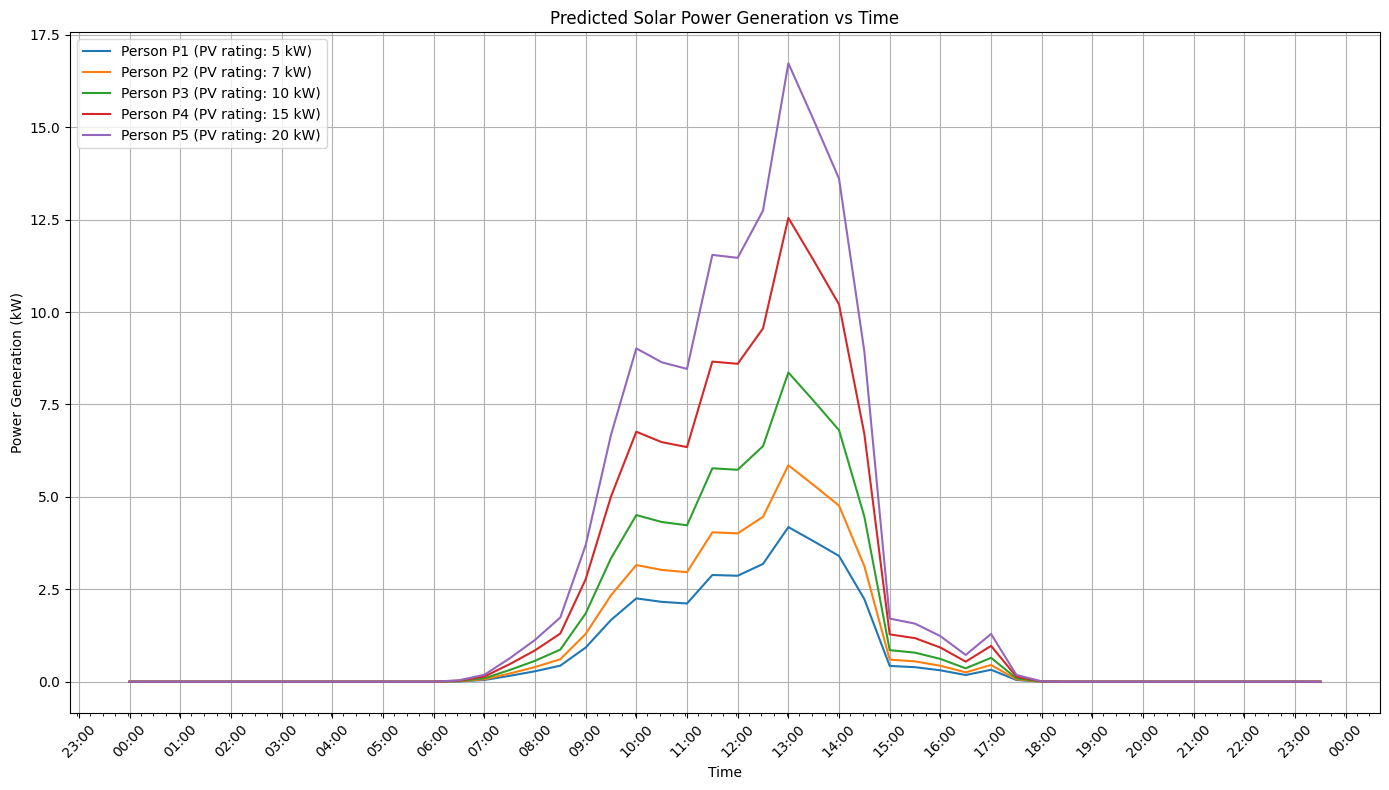

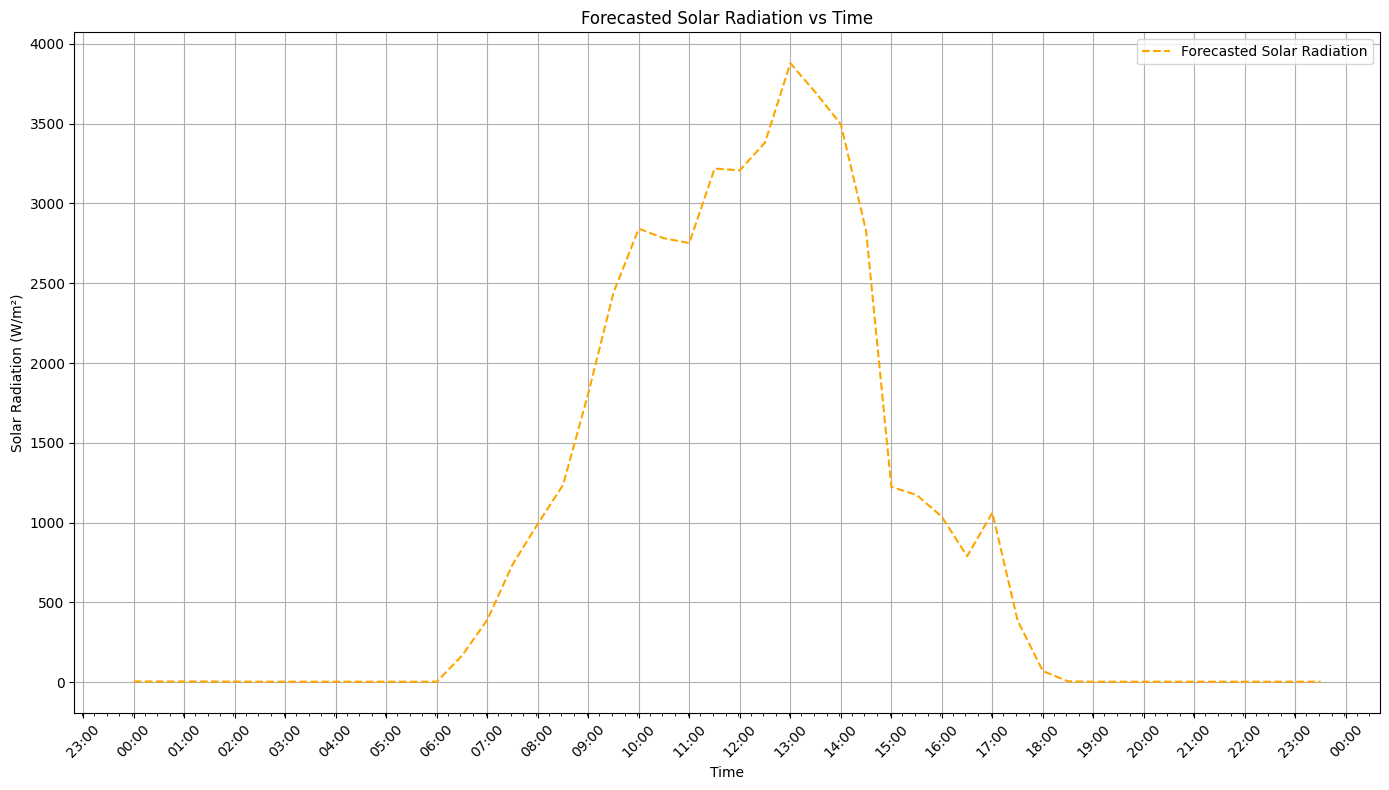

In [54]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

# PV ratings for five people
pv_ratings = np.array([5, 7, 10, 15, 20])  # kW ratings for P1, P2, ..., P5
eta = 0.25  # efficiency

# Forecast data preparation
day_temp_pred = day_temp_pred.ravel()
day_rad_pred = day_rad_pred.ravel()
day_PCP1_pred = day_PCP1_pred.ravel()

# Create a DataFrame with time data
day_data = pd.DataFrame({'Date_time': pd.date_range(start=start_time, periods=len(day_rad_pred), freq='30min')})

# Calculate solar power forecast for each person
for i, rating in enumerate(pv_ratings, start=1):
    T_C_forecasted = day_temp_pred + (NOCT - 20) * (day_rad_pred / G_STC)
    P_PV_forecasted = (rating * eta * P_STC * F_PV * (day_rad_pred / G_STC) *
                       (1 + (T_C_forecasted - T_STC) * C_T)) / 100000
    P_PV_forecasted[P_PV_forecasted < 0] = 0
    day_data[f'P_PV_forecasted_P{i}'] = P_PV_forecasted

# Plotting solar power generation for each person
fig1, ax1 = plt.subplots(figsize=(14, 8))
for i in range(1, 6):
    ax1.plot(day_data['Date_time'], day_data[f'P_PV_forecasted_P{i}'], label=f'Person P{i} (PV rating: {pv_ratings[i-1]} kW)')
ax1.set_xlabel('Time')
ax1.set_ylabel('Power Generation (kW)')
ax1.set_title('Predicted Solar Power Generation vs Time')
ax1.legend(loc='upper left')
ax1.xaxis.set_major_locator(mdates.HourLocator())
ax1.xaxis.set_minor_locator(mdates.MinuteLocator(interval=15))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax1.tick_params(axis='x', rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

# Plotting solar radiation
fig2, ax2 = plt.subplots(figsize=(14, 8))
ax2.plot(day_data['Date_time'], day_rad_pred, color='orange', label='Forecasted Solar Radiation', linestyle='--')
ax2.set_xlabel('Time')
ax2.set_ylabel('Solar Radiation (W/m²)')
ax2.set_title('Forecasted Solar Radiation vs Time')
ax2.xaxis.set_major_locator(mdates.HourLocator())
ax2.xaxis.set_minor_locator(mdates.MinuteLocator(interval=15))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax2.tick_params(axis='x', rotation=45)
ax2.legend(loc='upper right')
plt.grid()
plt.tight_layout()
plt.show()


In [55]:
data.head()

,Date_time,Temperature,Hi Temp,Low Temp,Out Hum,Dew Pt.,WindSpeed,Wind Dir,Wind Run,Hi Speed,...,PCP3,PCP4,PCP5,PCP6,PCP7,PCP8,PCP9,PCP10,T_C,P_PV
0,2023-04-01 00:30:00,28.0,28.0,27.9,83.0,24.8,1.6,SSE,0.8,6.4,...,20.241,37.930,23.344,20.281,17.624,14.000,21.654,13.478,28.0,0.0
1,2023-04-01 01:00:00,28.1,28.1,27.9,83.0,24.9,0.0,ESE,0.0,3.2,...,20.131,37.853,23.441,20.299,17.610,11.863,22.219,12.865,28.1,0.0
2,2023-04-01 01:30:00,27.7,28.1,27.7,84.0,24.8,1.6,S,0.8,8.0,...,19.668,37.904,23.119,20.535,17.501,11.306,22.855,12.577,27.7,0.0
3,2023-04-01 02:00:00,27.6,27.7,27.6,84.0,24.6,1.6,SSW,0.8,9.7,...,18.899,37.815,23.202,20.482,17.251,11.021,23.213,12.517,27.6,0.0
4,2023-04-01 02:30:00,27.6,27.6,27.5,85.0,24.8,0.0,SSW,0.0,6.4,...,18.442,37.701,23.026,20.417,16.926,10.747,23.334,12.670,27.6,0.0


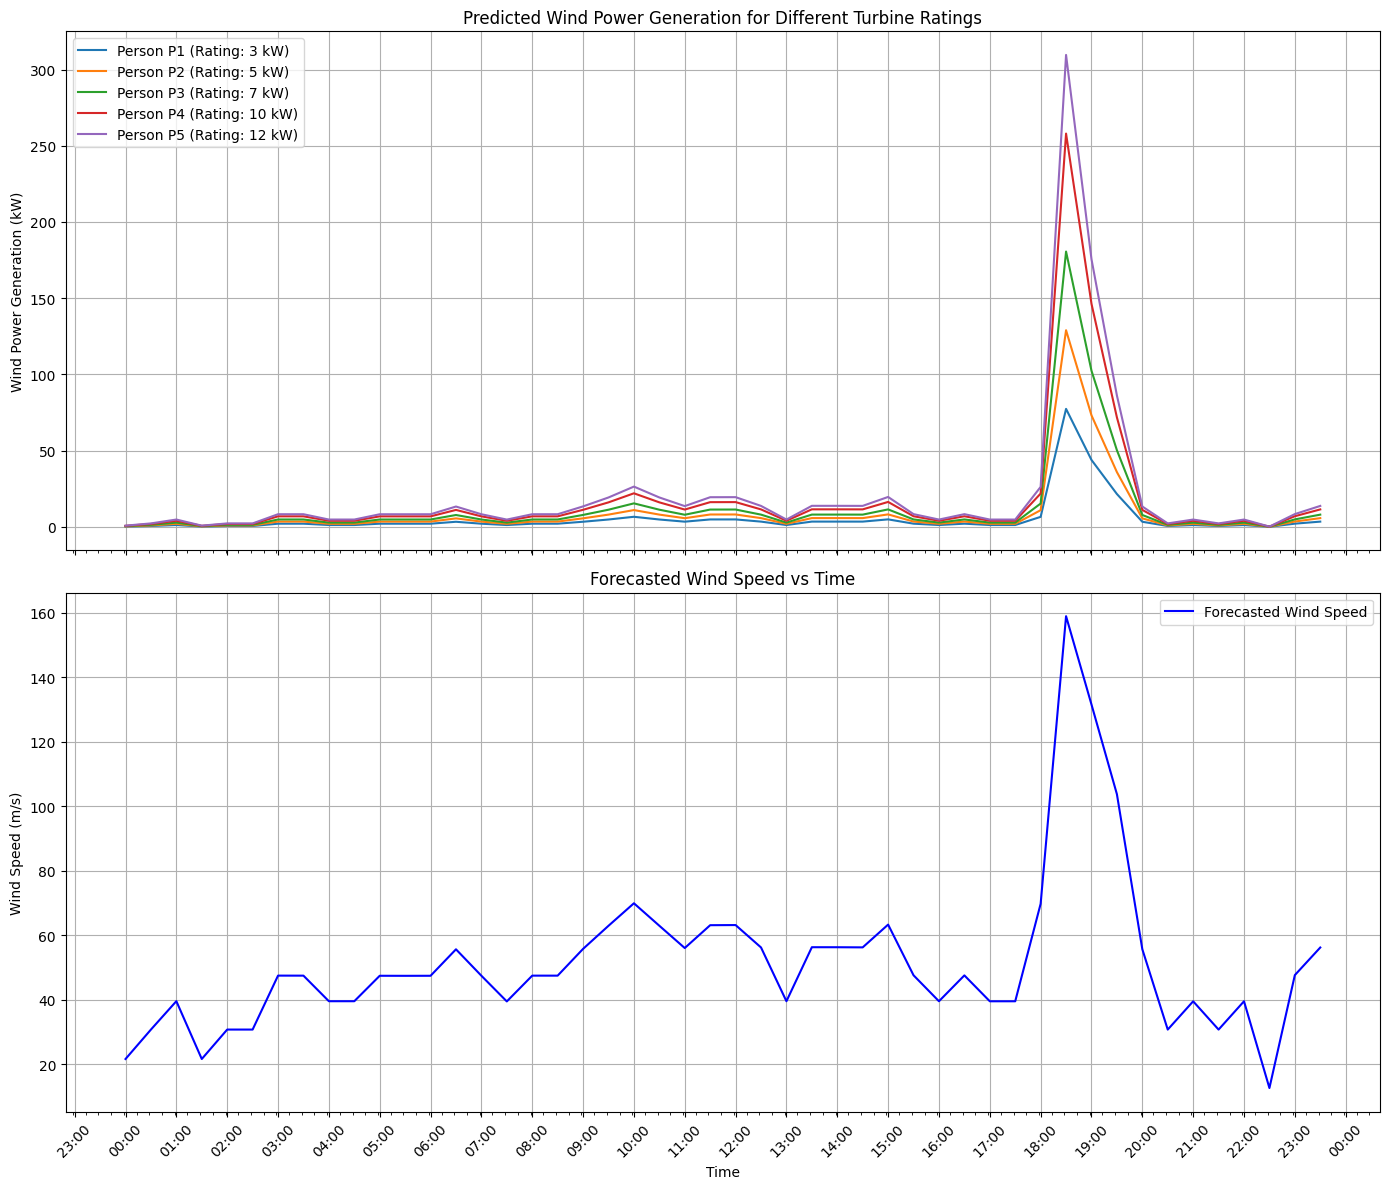

In [56]:
# Define wind turbine ratings for each person in kW
wind_ratings = np.array([3, 5, 7, 10, 12])  # Example ratings in kW for P1, P2, ..., P5
rho = 1.225  # Air density in kg/m³
A = 3        # Swept area in m² (example value)
eta = 0.35   # Efficiency of the turbine

# Ensure wind predictions are in 1D
day_wind_pred = day_wind_pred.ravel()

# Calculate wind power for each person
# day_data = pd.DataFrame({'DATE_TIME': pd.date_range(start=start_time, periods=len(day_wind_pred), freq='30min')})
for i, rating in enumerate(wind_ratings, start=1):
    wind_power_forecasted = (0.5 * rho * A * eta * rating * (day_wind_pred ** 3)) / 100000  # Convert to kW
    wind_power_forecasted[wind_power_forecasted < 0] = 0

    day_data[f'Wind_forecasted_P{i}'] = wind_power_forecasted

# Plotting wind power generation and wind speed
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# Plotting wind power generation for each person
for i in range(1, 6):
    ax1.plot(day_data['Date_time'], day_data[f'Wind_forecasted_P{i}'], label=f'Person P{i} (Rating: {wind_ratings[i-1]} kW)')

# Customize wind power generation plot
ax1.set_ylabel('Wind Power Generation (kW)')
ax1.set_title('Predicted Wind Power Generation for Different Turbine Ratings')
ax1.legend(loc='upper left')
ax1.grid()

# Plotting forecasted wind speed
ax2.plot(day_data['Date_time'], day_wind_pred, color='blue', label='Forecasted Wind Speed')
ax2.set_xlabel('Time')
ax2.set_ylabel('Wind Speed (m/s)')
ax2.set_title('Forecasted Wind Speed vs Time')
ax2.legend()
ax2.grid()

# Formatting the x-axis to show time every hour with 15-minute minor ticks
ax2.xaxis.set_major_locator(mdates.HourLocator())
ax2.xaxis.set_minor_locator(mdates.MinuteLocator(interval=15))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


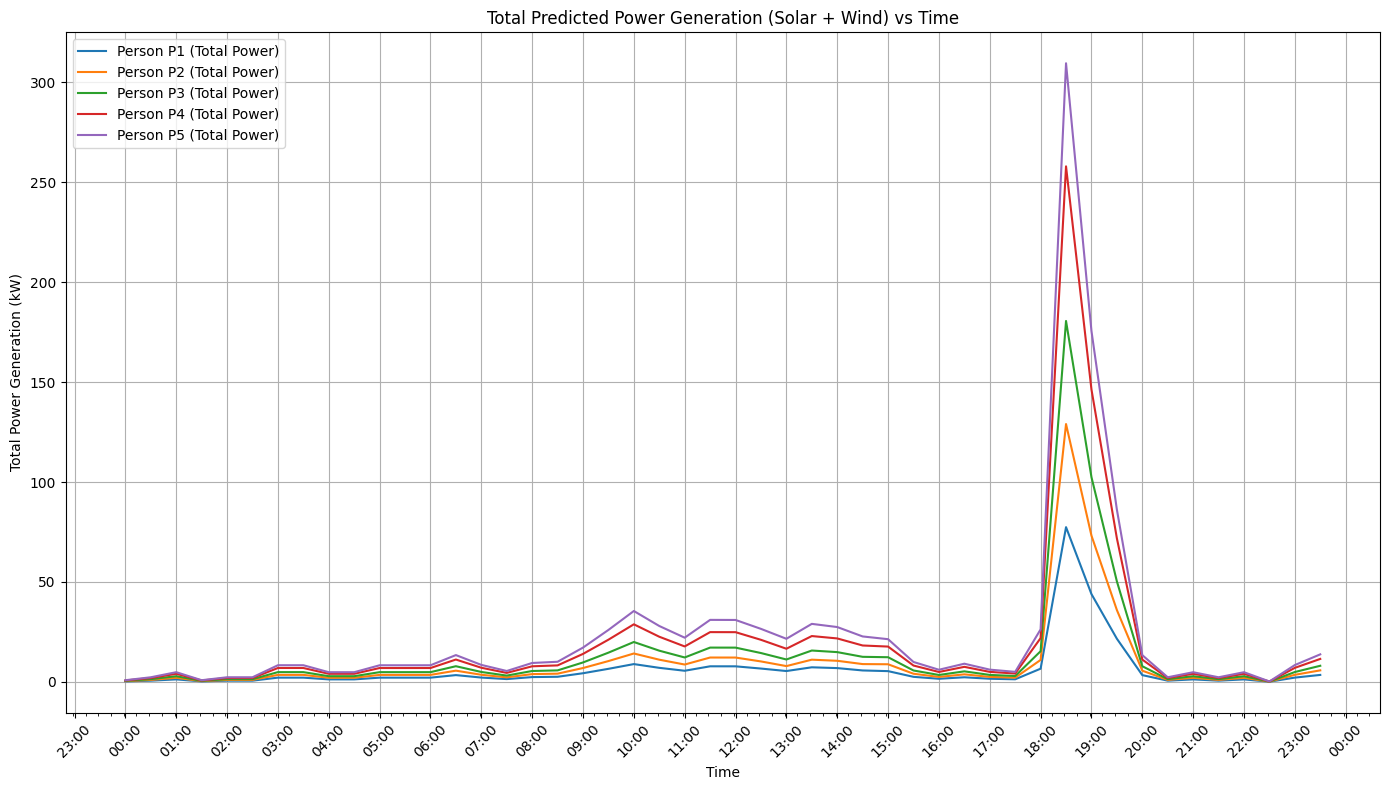

In [57]:
# Adding total power calculation by combining solar and wind power for each person
for i in range(1, 6):
    day_data[f'Total_Power_P{i}'] = day_data[f'P_PV_forecasted_P{i}'] + day_data[f'Wind_forecasted_P{i}']

# Plotting total power generation for each person
fig, ax = plt.subplots(figsize=(14, 8))

for i in range(1, 6):
    ax.plot(day_data['Date_time'], day_data[f'Total_Power_P{i}'], label=f'Person P{i} (Total Power)')

# Customize the plot
ax.set_xlabel('Time')
ax.set_ylabel('Total Power Generation (kW)')
ax.set_title('Total Predicted Power Generation (Solar + Wind) vs Time')
ax.legend(loc='upper left')
ax.xaxis.set_major_locator(mdates.HourLocator())
ax.xaxis.set_minor_locator(mdates.MinuteLocator(interval=15))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.grid()
plt.show()


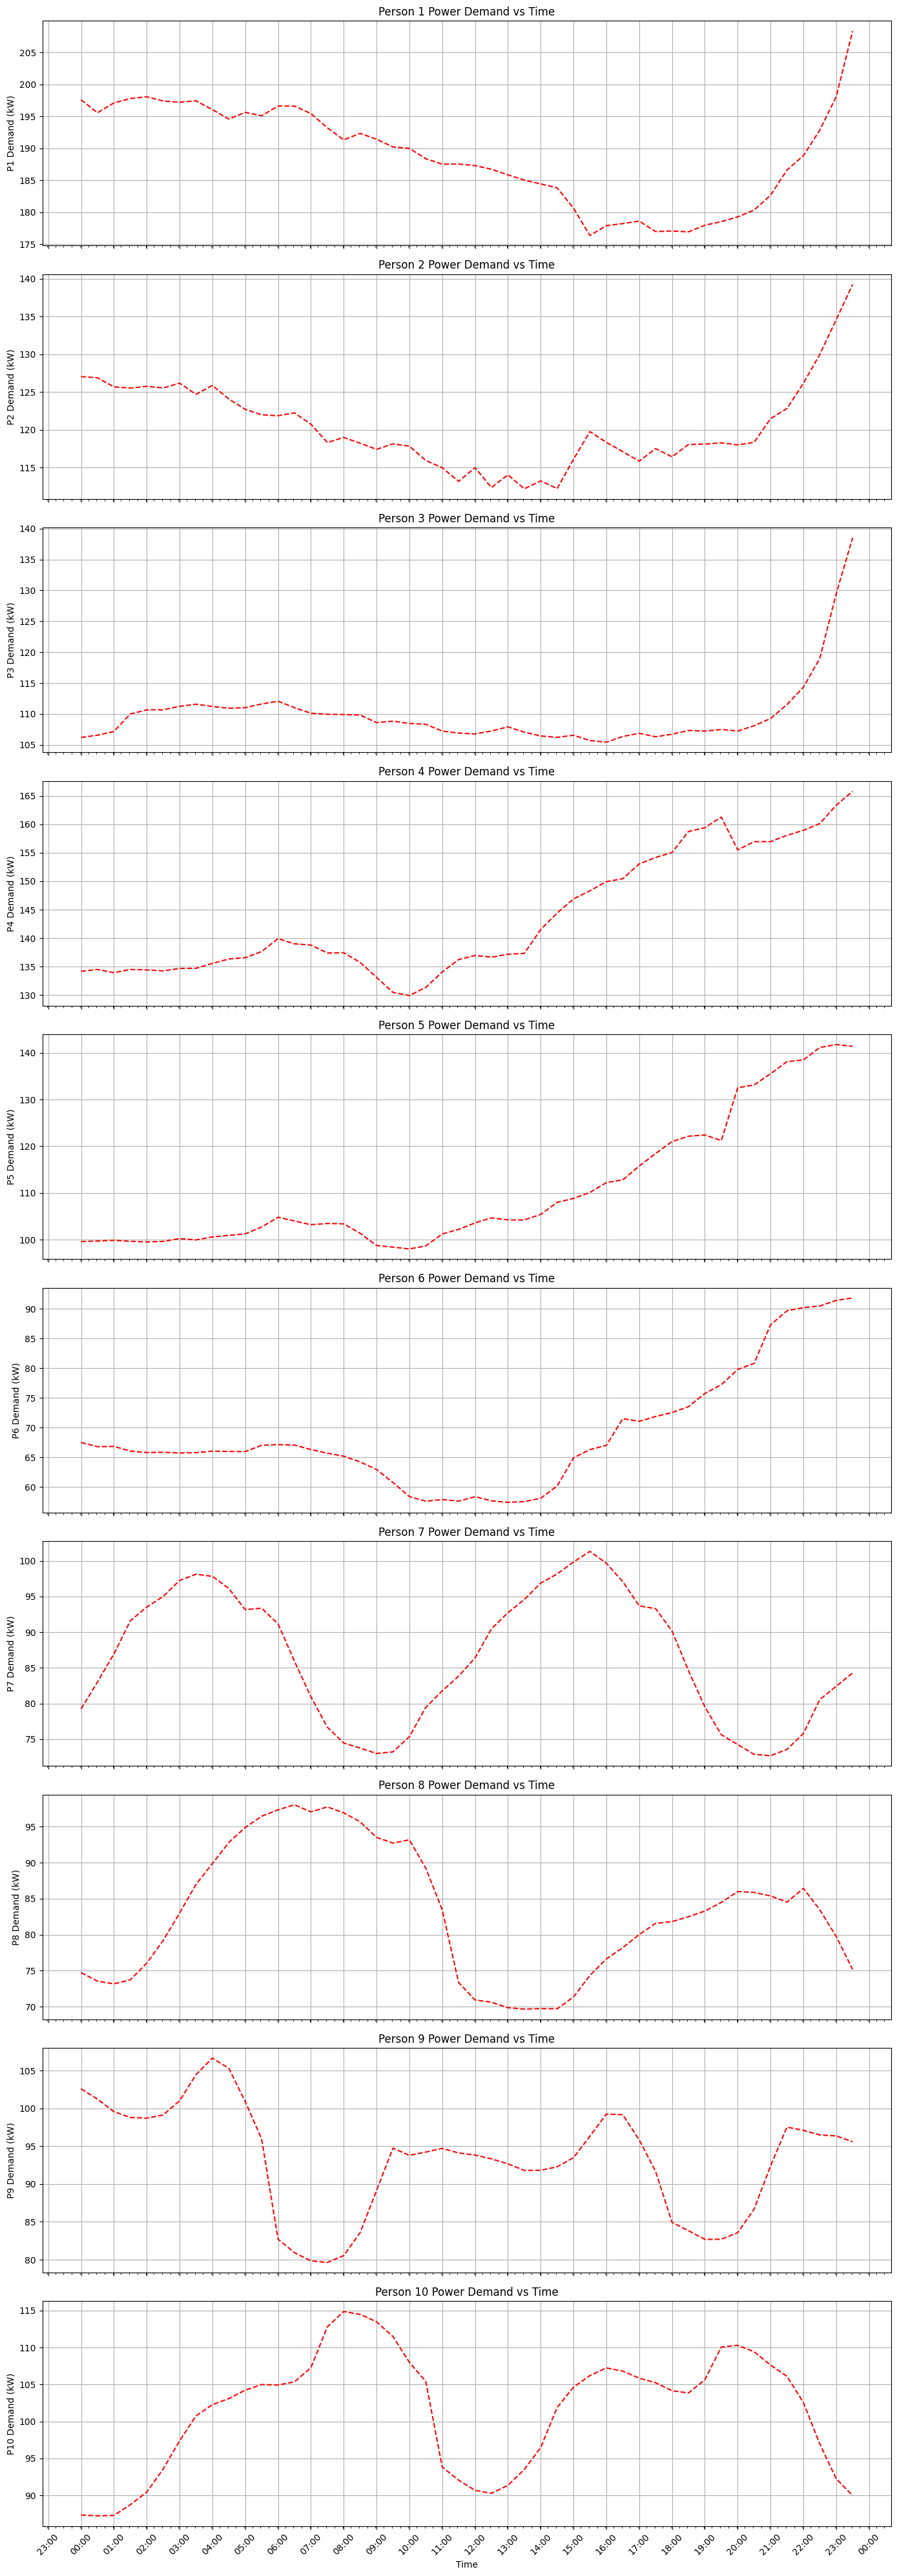

In [92]:

# Create a 10-row figure with individual subplots for each person's power demand
fig, axs = plt.subplots(10, 1, figsize=(14, 40), sharex=True)

# Loop through each person (1 to 10) and plot their power demand in a separate subplot
for i in range(1, 11):
    ax = axs[i - 1]
    ax.plot(day_data['Date_time'], globals()[f'day_PCP{i}_pred'], color='red', linestyle='--')
    ax.set_ylabel(f'P{i} Demand (kW)')
    ax.set_title(f'Person {i} Power Demand vs Time')
    ax.xaxis.set_major_locator(mdates.HourLocator())
    ax.xaxis.set_minor_locator(mdates.MinuteLocator(interval=15))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.tick_params(axis='x', rotation=45)

# Label the shared x-axis and add grid lines
axs[-1].set_xlabel('Time')
for ax in axs:
    ax.grid()

plt.tight_layout()
plt.show()


# Plotting net power demand (Demand - Total Power Generation) for each person
# fig3, ax3 = plt.subplots(figsize=(14, 8))
# for i in range(1, 6):
#     # Net power is demand minus the combined solar and wind power generation
#     net_power =  day_data[f'Total_Power_P{i}']-(day_PCP1_pred / 10)
#     ax3.plot(day_data['Date_time'], net_power, label=f'Person P{i} (Total Power)')
# ax3.set_xlabel('Time')
# ax3.set_ylabel('Net Power for P2P (kW)')
# ax3.set_title('TNPh = Total net Power of the Energy sharing (Total Power Generation - Demand) vs Time')
# ax3.set_ylim(-300, 300)  # Adjust y-axis limit for net power generation as needed
# ax3.legend(loc='upper left')
# ax3.xaxis.set_major_locator(mdates.HourLocator())
# ax3.xaxis.set_minor_locator(mdates.MinuteLocator(interval=15))
# ax3.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
# ax3.tick_params(axis='x', rotation=45)
# plt.grid()
# plt.tight_layout()
# plt.show()

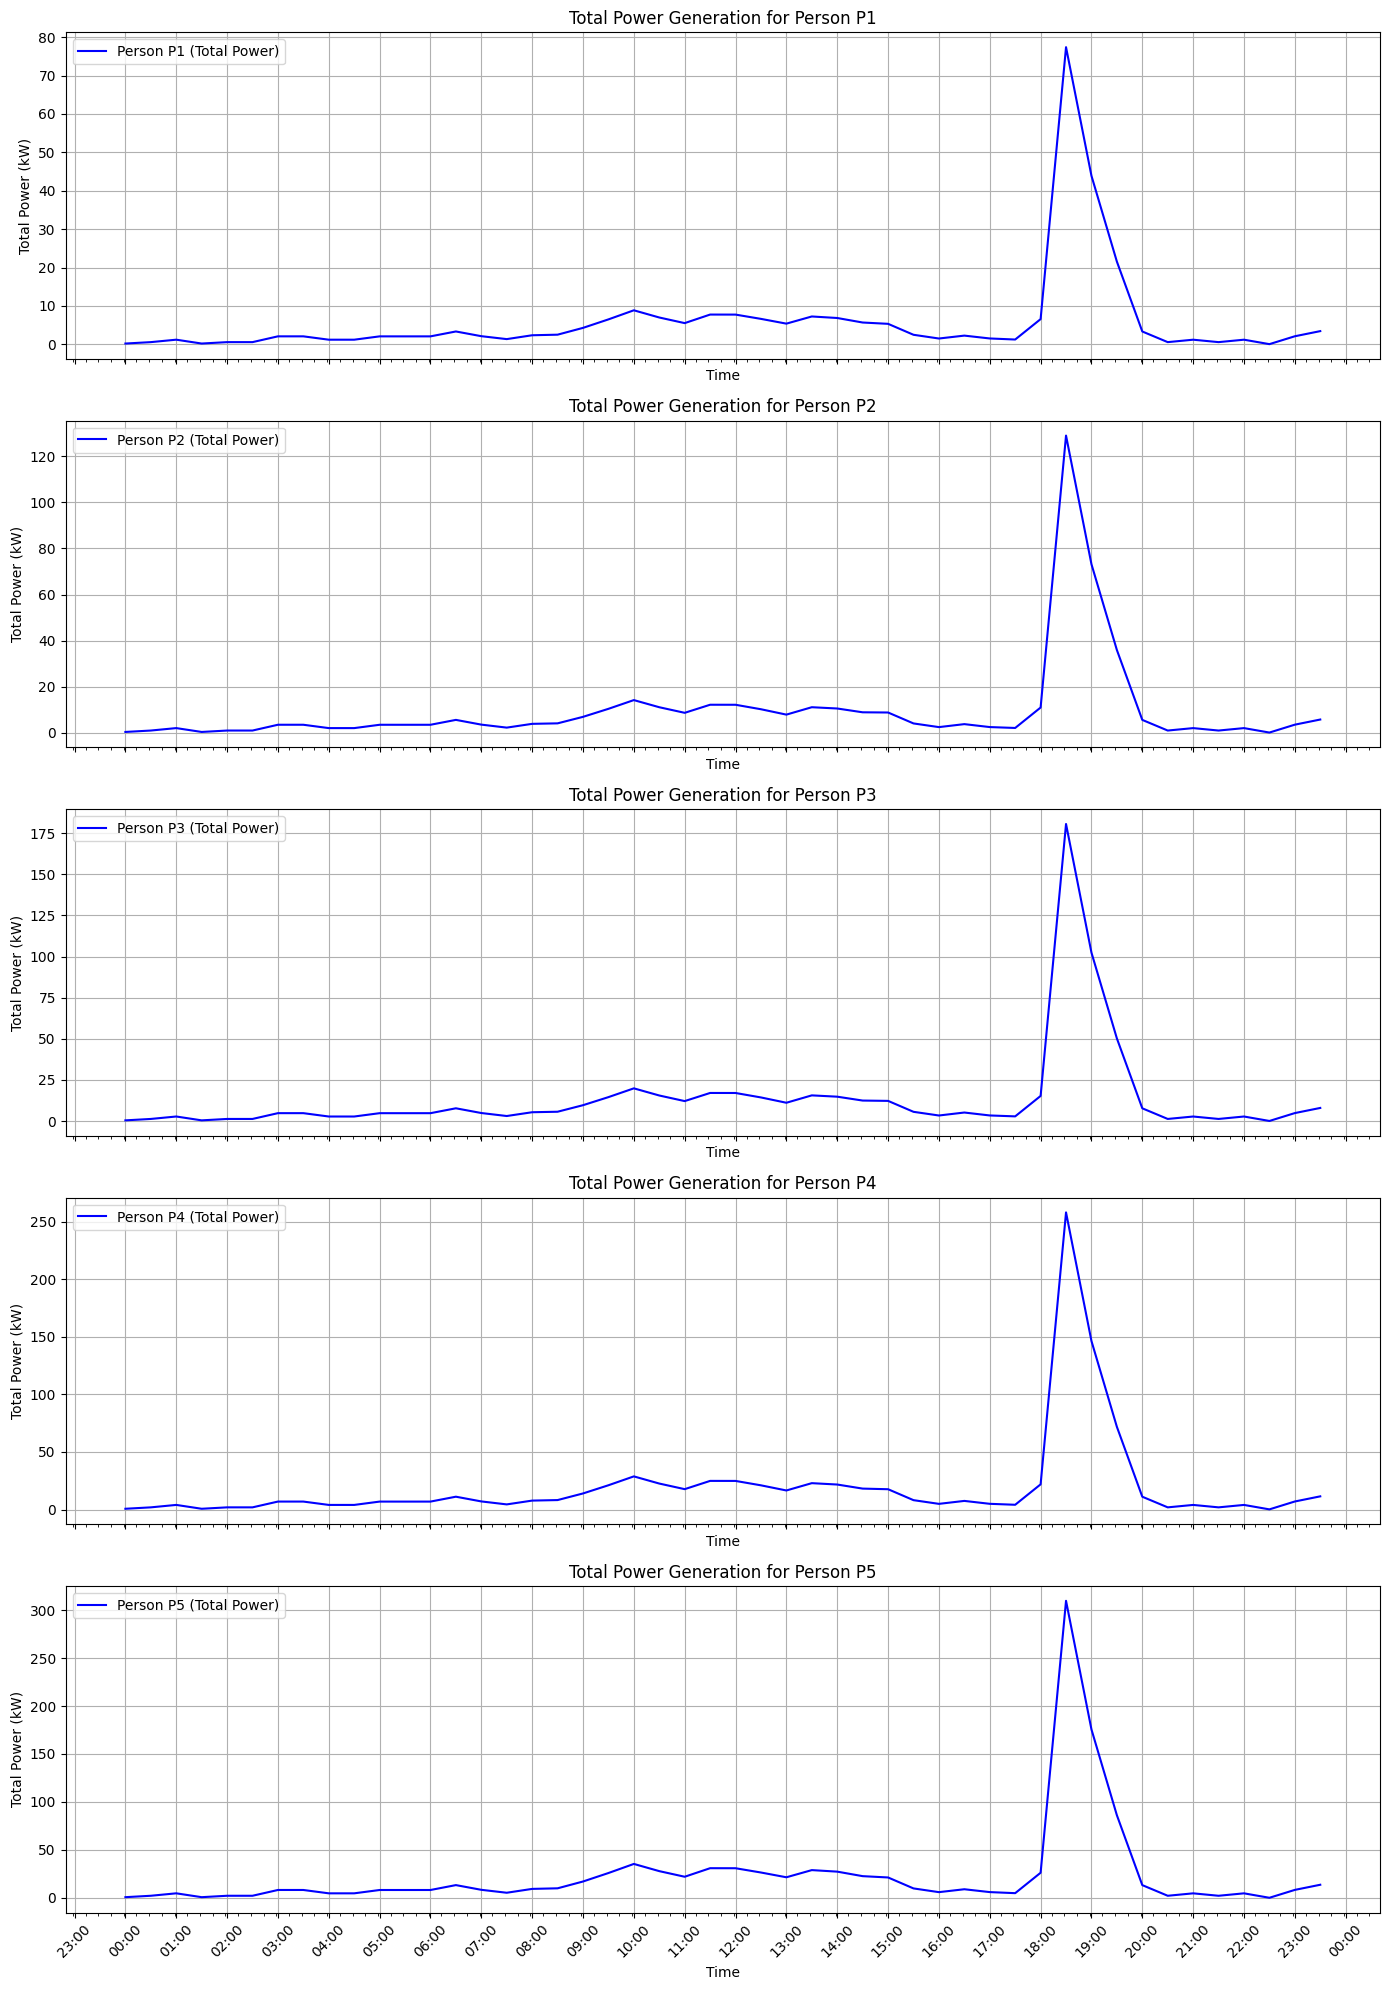

In [93]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

# Setting up the figure for 5 subplots
fig, axes = plt.subplots(5, 1, figsize=(14, 20), sharex=True)  # 5 rows, 1 column

for i in range(1, 6):
    # Plotting total power for each person in a separate subplot
    axes[i - 1].plot(day_data['Date_time'], day_data[f'Total_Power_P{i}'], label=f'Person P{i} (Total Power)', color='blue')
    axes[i - 1].set_ylabel('Total Power (kW)')
    axes[i - 1].set_title(f'Total Power Generation for Person P{i}')
    axes[i - 1].legend(loc='upper left')
    axes[i - 1].xaxis.set_major_locator(mdates.HourLocator())
    axes[i - 1].xaxis.set_minor_locator(mdates.MinuteLocator(interval=15))
    axes[i - 1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    axes[i - 1].tick_params(axis='x', rotation=45)
    axes[i - 1].grid()

# Shared x-label and layout adjustments
axes[0].set_xlabel('Time')
axes[1].set_xlabel('Time')
axes[2].set_xlabel('Time')
axes[3].set_xlabel('Time')
axes[4].set_xlabel('Time')
plt.tight_layout()
plt.show()


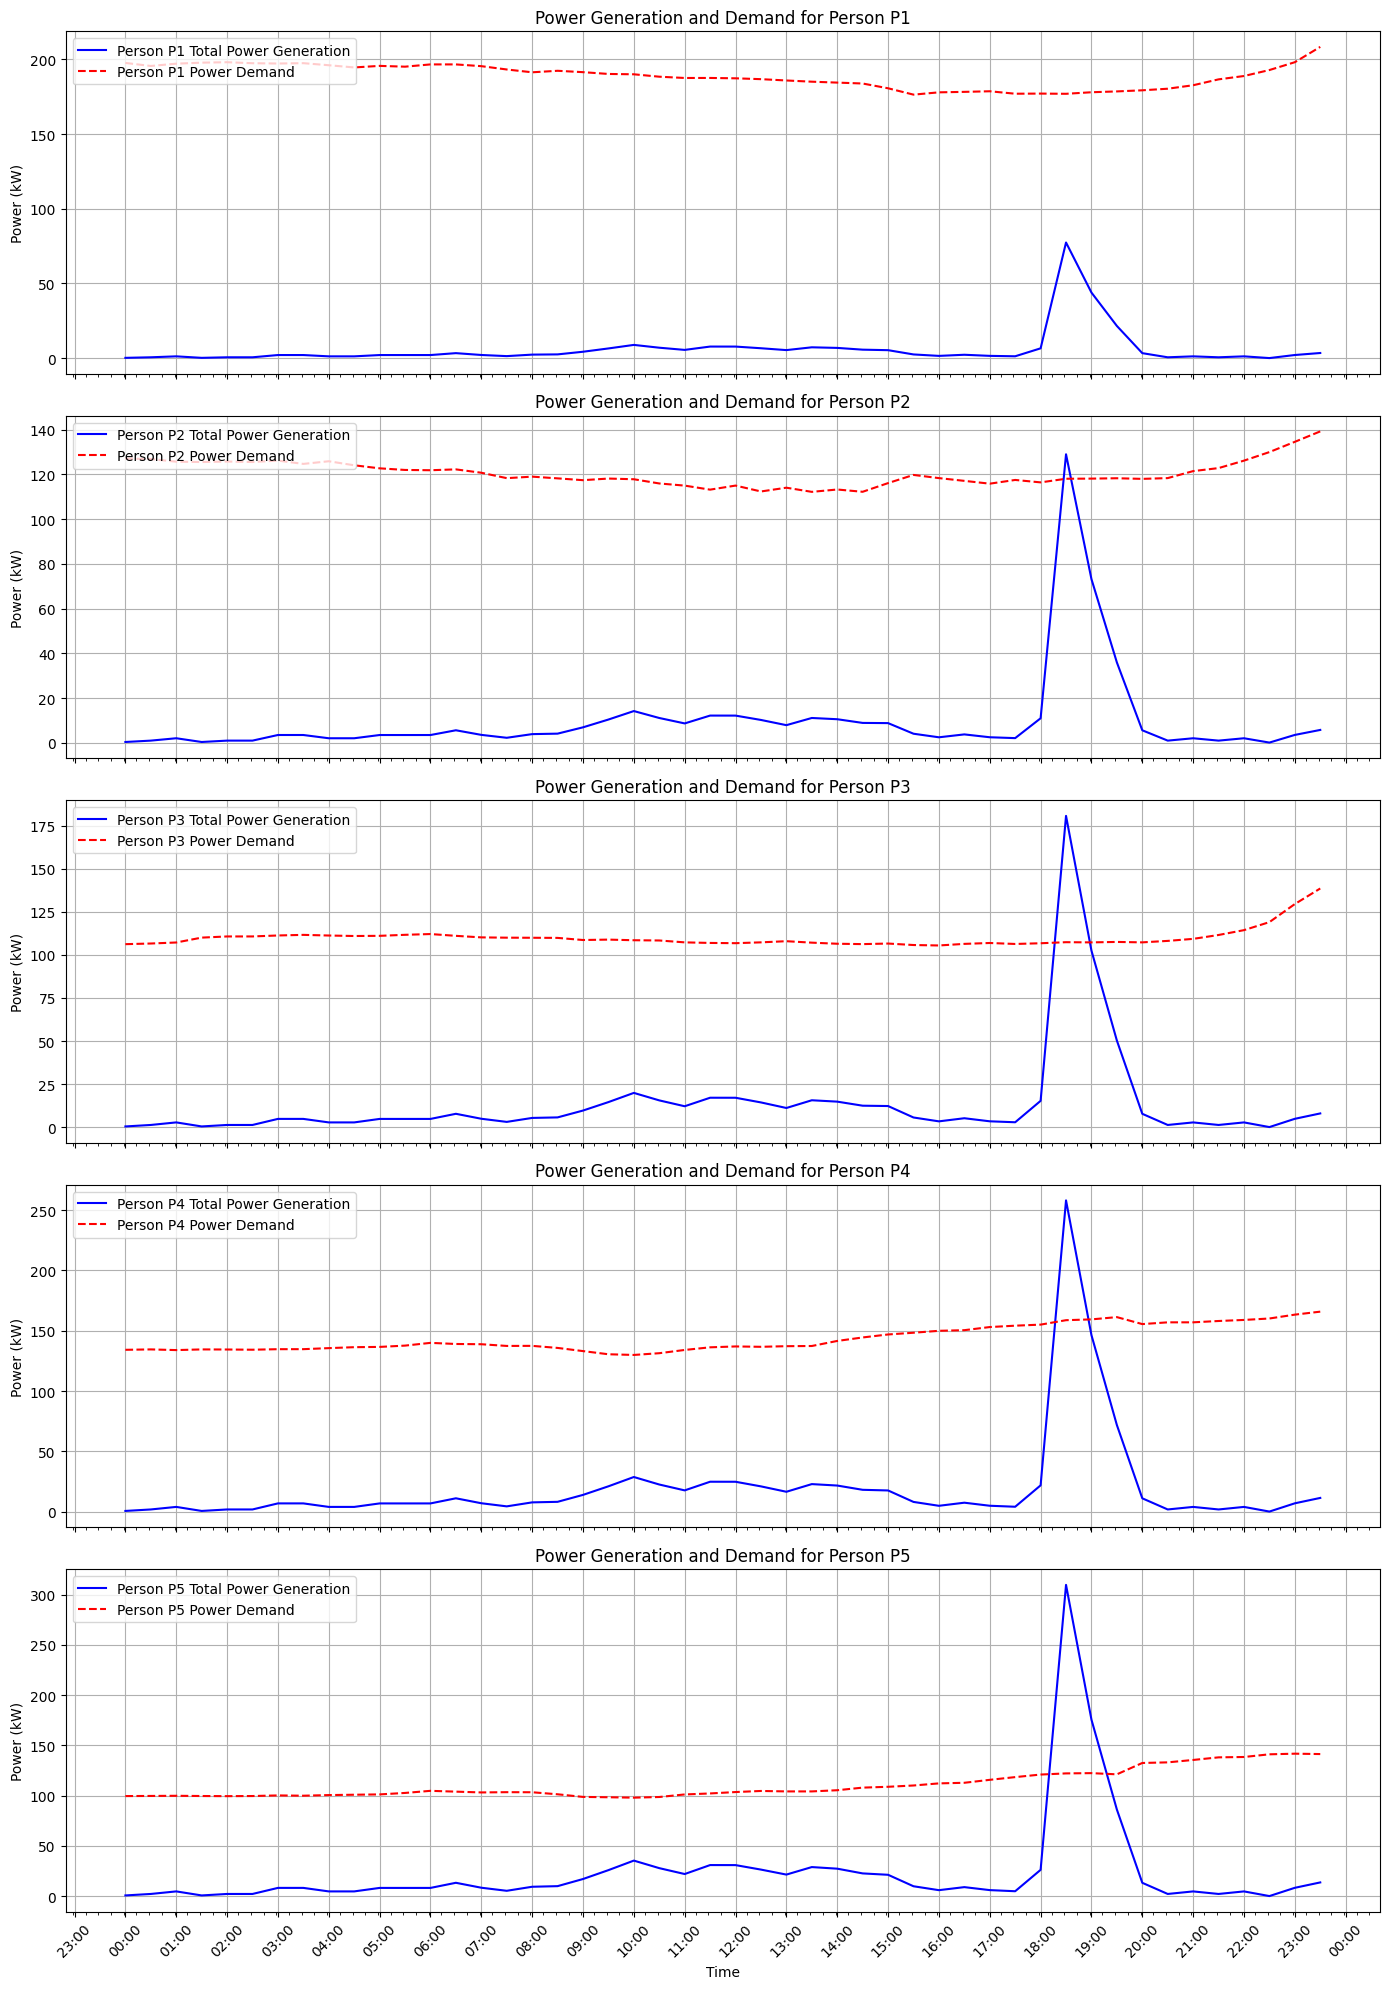

In [96]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

# Setting up the figure with 5 subplots (one for each person)
fig, axs = plt.subplots(5, 1, figsize=(14, 20), sharex=True)  # 5 rows, 1 column, shared x-axis

for i in range(1, 6):
    # Plot total power generation (solar + wind)
    axs[i - 1].plot(day_data['Date_time'], day_data[f'Total_Power_P{i}'], label=f'Person P{i} Total Power Generation', color='blue')

    # Plot total power demand
    axs[i - 1].plot(day_data['Date_time'], globals()[f'day_PCP{i}_pred'], label=f'Person P{i} Power Demand', color='red', linestyle='--')

    # Customize subplot
    axs[i - 1].set_ylabel(f'Power (kW)')
    axs[i - 1].set_title(f'Power Generation and Demand for Person P{i}')
    axs[i - 1].legend(loc='upper left')
    axs[i - 1].xaxis.set_major_locator(mdates.HourLocator())
    axs[i - 1].xaxis.set_minor_locator(mdates.MinuteLocator(interval=15))
    axs[i - 1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    axs[i - 1].tick_params(axis='x', rotation=45)
    axs[i - 1].grid()

# Shared x-axis label and layout adjustments
axs[-1].set_xlabel('Time')
plt.tight_layout()
plt.show()


In [90]:
from tensorflow.keras.models import load_model

# Define the directory path where models will be saved
save_dir = '/content/drive/MyDrive/saved_models/'

# Loop through each model and save it
model_rad.save(f'{save_dir}solar_model.h5')
model_wind.save(f'{save_dir}wind_model.h5')
model_temp.save(f'{save_dir}temp_model.h5')
for i in range(1, 11):
    model = globals()[f'model_PCP{i}']  # Access model_PCP1, model_PCP2, ..., model_PCP10
    model.save(f'{save_dir}model_PCP{i}.h5')
